<a href="https://colab.research.google.com/github/Horlabrainmoore/Algorithms/blob/dependabot%2Fpip%2Fpip-ea0e095d37/examples/post-processings/farmland-coverage/farmland-coverage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Farmland Coverage Analysis

This notebook demonstrates how to use a Visual Prompting model to analyze the area coverage of different types of land or structures on satellite images.

In particular, we are going to show you:

1. How to use the `Predictor` class to extract the segmentation mask
2. How to visualize the segmentation mask
3. How to extract the percentage pixel coverage and visualize it in a pie chart

### Installation

In [4]:
!pip install landingai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.6/276.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 

### Prerequisite: Deploy a Visual Prompting Model

Before performing the coverage analsis, we have already trained a Visual Prompting model in LandingLens, and deployed it to a web endpoint via [Cloud Deployment](https://support.landing.ai/landinglens/docs/cloud-deployment).

The following cell defines the api_key needed to access the model and its endpoint with endpoint_id.

In [5]:
#@title Set the following variables as needed for your setup
api_key = "land_sk_aMemWbpd41yXnQ0tXvZMh59ISgRuKNRKjJEIUHnkiH32NBJAwf"
endpoint_id = "63035608-9d24-4342-8042-e4b08e084fde"

### Load Images

Here, we load three test images for the coverage analysis.

In [6]:
from PIL import Image as PILImage
from landingai.storage.data_access import fetch_from_uri

img_paths = [
    fetch_from_uri("https://drive.google.com/uc?id=1z7KiNcXmfbNQL-rz6NMv7eVTBh-CnpAs"),
    fetch_from_uri("https://drive.google.com/uc?id=1Vfbrdj8UFI03dv9fncw2OWWaadGeWBDq"),
    fetch_from_uri("https://drive.google.com/uc?id=1kauz5WyB3rJb0_9qM1MukVmHkNJ9t1vQ"),
]

images = [PILImage.open(path) for path in img_paths]

### Example Image

Let's take a look at one of the test images.

The model is trained to detect four classes:

1. Green field
2. Brown field
3. Trees
4. Structure

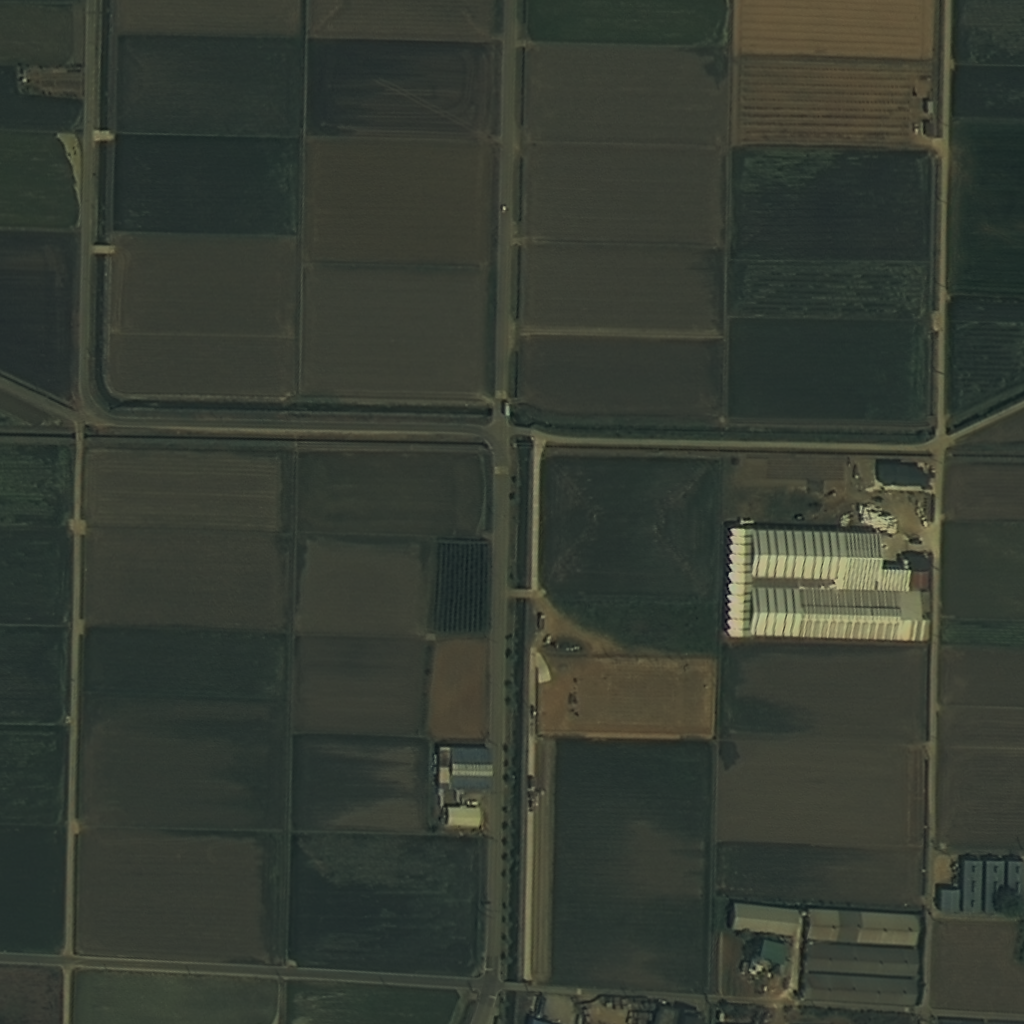

In [7]:
display(images[0])

### Run Inference

In the following cell, we use the `Predictor` call to get the predicted segmentation masks for each image.

The predictor returns a list of `SegmentationPrediction` instances for each image.

We collect all of the prediction results into a list for further processing.

In [8]:
from landingai.predict import Predictor

predictor = Predictor(endpoint_id, api_key=api_key)
predictions = []
for img in images:
        predictions.extend(predictor.predict(img))

TypeError: function takes at most 16 arguments (17 given)

### Example Image with Prediction

Before moving forward, it's helpful to do a sanity check to see if the prediction result looks reasonable to you.  

To do that, we get the predictions of a single image, and visualize it like below.

Note: For this demo, we didn't spend time on improving model performance, so the segmentation mask may not be perfect.

In [ ]:
from landingai.visualize import overlay_predictions

predictions = predictor.predict(images[0])
color_map = {
    "Trees": "green",
    "Structure": "yellow",
    "Brown Field": "red",
    "Green Field": "blue",
}
options = {
    "color_map": color_map
}
display(overlay_predictions(predictions, images[0], options=options))

### Post-Processing: Compute the Coverage of Each Class

Now we that have collected a list of predictions (segmentation masks) we can call the `segmentation_class_pixel_coverage()` API to calculate the percentage of the pixel coverage of each class over all the images.

The output (`coverage`) is a dictionary where the key is the predicted class index, and the value is a tuple of the coverage percentage and the predicted class name.

The coverage percentage is calculated as follow:

`(number of predicted pixels for this class) / (total number of pixels)`

Note: Alternatively, we can also get the absolute coverage value (the number of predicted pixels for each class) by running `segmentation_class_pixel_coverage(predictions, coverage_type='absolute')`. See the API doc in `postprocess.py` for more details.

In [ ]:
from landingai.postprocess import segmentation_class_pixel_coverage

coverage = segmentation_class_pixel_coverage(predictions)
coverage

### Visualize the Predictions in a Pie Chart

Now we that have the coverage data, we can process it to see the predictions in a pie chart.

In [ ]:
import matplotlib.pyplot as plt

def generate_pie_chart(data: dict[int, (float, str)], color_map: dict[str, str]) -> None:
    """Generate a pie chart from the coverage data"""

    labels = [val[1] for val in data.values()]
    colors = [color_map[label] for label in labels]
    sizes = [val[0] for val in data.values()]
    unclassified_pixels = 1 - sum(sizes)
    sizes.append(unclassified_pixels)
    labels.append("unclassified")
    colors.append("gray")
    _, ax = plt.subplots()
    ax.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", shadow=True, startangle=90)

In [ ]:
generate_pie_chart(coverage, color_map=color_map)

In [ ]:
!curl --location 'https://mt5.mtapi.io/Connect?user=406783246&password=Brainmoore$004&host=192.168.0.103&port=50080&id=Exness-MT5Real10' \
--header 'Accept: text/plain'

curl --location 'https://mt5.mtapi.io/Connect?user=406783246&password=Brainmoore$004&host=192.168.0.103&port=50080&id=Exness-MT5Real10' \
--header 'Accept: text/plain'